# Import Necessary Libraries and crosslinked_mfp_analysis

In [19]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt

In [20]:
from crosslinked_mfp_analysis.crosslinked_mfp_analysis import (
    say_hello,
    stress_strain,
    analyze_ion_surroundings,
    analyze_og312_surroundings,
    analyze_ion_coordination_bonds,
    analyze_covalent_bonds
)

## Preview simulation files

In [21]:
%ls fe3p_ions_simulation


8_T370_P1.dcd           ionized.psf                 tensile_test.dcd
8_T370_P1_original.dcd  output_every_10th.dcd       tensile_test_original.dcd
9_T300_P1.dcd           stress_strain_original.txt
9_T300_P1_original.dcd  stress_strain.txt


## Plot stress-strain curves

In [22]:
# Read stress_strain.txt into a pandas dataframe.
sim_path = "fe3p_ions_simulation"
df = stress_strain.read_stress_strain(f'{sim_path}/stress_strain.txt', window_size=1000)
df

,index,Strain,Pxx (kPa),Pyy (kPa),Pzz (kPa),Moving_Avg_Pzz (MPa),Moving_Avg_Pxx (MPa),Moving_Avg_Pyy (MPa),Toughness (MJ/m$^3$)
0,0,9.028776e-16,-58163.720317,55554.598748,-19947.598069,NaN,NaN,NaN,0.000000
1,1,1.000000e-05,-106831.553583,57776.921523,-26205.028497,NaN,NaN,NaN,-0.000231
2,2,2.000000e-05,3436.782132,-5399.747012,34385.822710,NaN,NaN,NaN,-0.000190
3,3,3.000000e-05,-19988.172204,-77557.116732,31716.655803,NaN,NaN,NaN,0.000141
4,4,4.000000e-05,-169211.292560,-51590.735624,-120030.743974,NaN,NaN,NaN,-0.000301
...,...,...,...,...,...,...,...,...,...
968523,968523,9.685230e+00,-21311.511442,-4414.812208,9318.939462,0.587189,-0.261125,-0.618698,2975.773554
968524,968524,9.685240e+00,-24650.533359,-2841.665104,-805.003566,0.593676,-0.288528,-0.639063,2975.773596
968525,968525,9.685250e+00,-6897.006645,15652.602663,9017.540920,0.612790,-0.287561,-0.638794,2975.773637
968526,968526,9.685260e+00,-2237.498333,-44839.605763,-12977.336713,0.594928,-0.288576,-0.670127,2975.773617


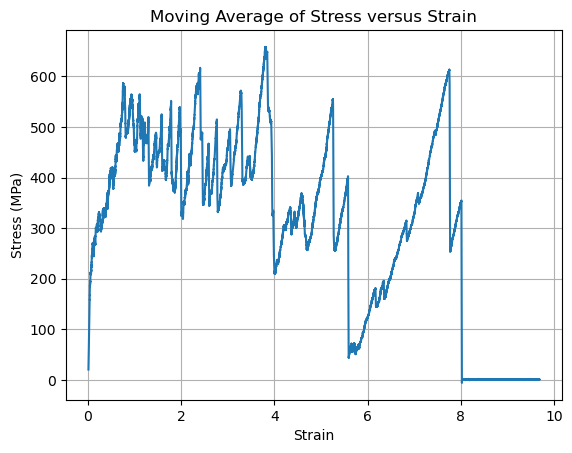

In [23]:
# Plot the moving average of stress versus strain.
plt.plot(df["Strain"],df["Moving_Avg_Pzz (MPa)"])
plt.xlabel('Strain')
plt.ylabel('Stress (MPa)')
plt.title('Moving Average of Stress versus Strain')
plt.grid()
plt.show()

## Analyze molecular dynamics trajectory

In [58]:
# Specify paths to .psf and .dcd files.
PSF = f"{sim_path}/ionized.psf"
DCD = [f"{sim_path}/8_T370_P1.dcd",
       f"{sim_path}/9_T300_P1.dcd",
       f"{sim_path}/tensile_test.dcd"]
# DCD = [f"{sim_path}/output_0.dcd",
#        f"{sim_path}/output_1.dcd",
#        f"{sim_path}/output_2.dcd"]
# Load the trajectory into an MDAnalysis Universe.
u = mda.Universe(PSF, DCD)
step = 2
end_idx = 333

/home/jjg9482/anaconda3/envs/mdanalysis/lib/python3.12/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


In [25]:
# from MDAnalysis.coordinates.DCD import DCDWriter
# for i, dcd in enumerate(DCD):
#     u = mda.Universe(PSF, dcd)
#     with DCDWriter(f'{sim_path}/output_{i}.dcd', u.atoms.n_atoms) as writer:
#         for ts in u.trajectory[::50]:
#             writer.write(u.atoms)

Use collect_ion_surroundings to make an atomgroup of atoms within the cutoff distance of each ion at each frame.

In [26]:
# Specify the cutoff for counting contacts with ions.
cutoff = 2.2

ion_surroundings = analyze_ion_surroundings.collect_ion_surroundings(universe=u,
                                                                     cutoff=cutoff,
                                                                     ion_type='FE3P',
                                                                     verbose=False,
                                                                     step=step)

Each list element in ion_surroundings contains a dictionary with information about the frame that corresponds to that list index. The 0th element represents the first frame.

Each list element is a dictionary where each key is the residue id of one ion and the value is an atom group of atoms that fall within the cutoff distance of that ion.

In [27]:
# Print the information about the atoms surrounding the ion with residue id '675' at the 0th frame.
print(ion_surroundings[0]['675'])


<AtomGroup [<Atom 4491: OE1 of type OG312 of resname DO2E, resid 55 and segid P4>, <Atom 17140: OH2 of type OT of resname TIP3, resid 862 and segid W>, <Atom 21007: OH2 of type OT of resname TIP3, resid 2151 and segid W>, <Atom 22233: CLA of type CLA of resname CLA, resid 537 and segid I>]>


## Plot the frequency of unique sets of atoms found within the cutoff distance of the ion

Use unique_surroundings_frequency to count the number of times each unique set of atom types is found around an ion at each frame. An example of a set of atom types is 'OT OT OG312', which indicates that there are two atoms of type 'OT' and one atom of type 'OG312' within the cutoff distance of a particular ion. This is to detect whether certain structures surrounding ions are forming more frequently than others throught the simulation.

In [28]:
surrounding_freq = analyze_ion_surroundings.unique_surroundings_frequency(surroundings_each_frame=ion_surroundings,
                                                                          verbose=False)

In [29]:
# Make a time series to plot interactions evolving over time.
durations = [20000000, 5000000, 100000000]
dumpfreqs = [500000, 50000, 500000]
timeseries=analyze_ion_surroundings.make_timeseries(durations, dumpfreqs)

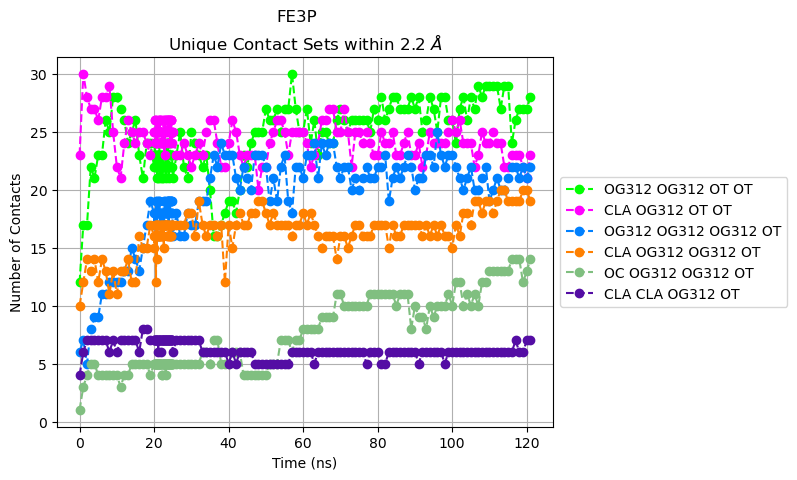

In [30]:
analyze_ion_surroundings.sort_and_plot_unique_surroundings(environments_over_time=surrounding_freq,
                                                           cutoff=cutoff,
                                                           timeseries=timeseries[:end_idx],
                                                           title="FE3P",
                                                           step=step,
                                                           max_entries=6)

The most frequent set of atoms within the cutoff distance at the end of the tensile test is two 'OG312' atoms and two 'OT' atoms.

## Plot count of each atom types within cutoff of any ion

Use count_atom_types_around_ion_over_time to count the nuumber of times each atom type is within the cutoff distance of an ion at each frame.

In [36]:
environments = analyze_ion_surroundings.count_atom_types_around_ion_over_time(ion_surroundings=(ion_surroundings))

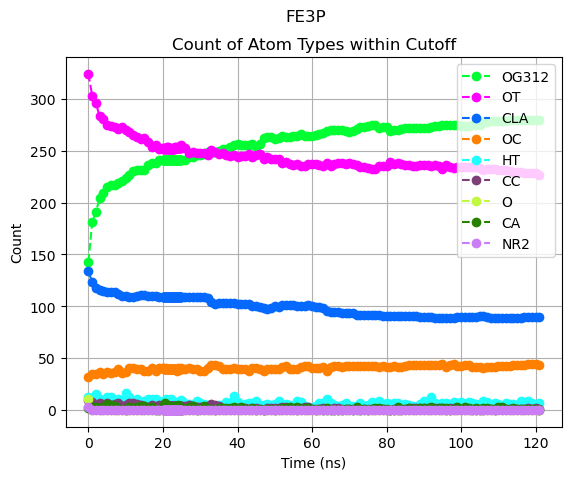

In [43]:
analyze_ion_surroundings.plot_counts_of_atom_types_around_ion(types_dict=environments,
                                                              timeseries=timeseries[:333],
                                                              title="FE3P",
                                                              normalize=False,
                                                              step=2)

In [45]:
protein_ion_coord = analyze_ion_coordination_bonds.protein_protein_ion_coordination(ion_surrounding_atoms_each_frame=ion_surroundings,
                                                                                    non_protein=['CLA', 'FE3P', 'HT', 'OT'])

In [46]:
for key, value in ion_surroundings[0].items():
    print(value.types)

['OG312' 'OT' 'OT' 'OT']
['CC' 'OC' 'OC' 'OT' 'OT' 'OT']
['OG312' 'OT' 'OT' 'CLA']
['OG312' 'OT' 'OT' 'CLA']
['OT' 'OT' 'CLA' 'CLA']
['O' 'OT' 'OT' 'OT']
['OG312' 'OT' 'OT' 'HT' 'CLA']
['OT' 'OT' 'OT' 'CLA']
['OT' 'OT' 'OT' 'HT' 'CLA']
['OG312' 'OT' 'OT' 'CLA']
['OG312' 'OG312' 'OT' 'CLA']
['CA' 'OG312' 'OG312' 'OT' 'OT']
['OT' 'OT' 'CLA' 'CLA']
['OT' 'OT' 'OT' 'HT' 'CLA']
['OT' 'CLA' 'CLA' 'CLA']
['OT' 'OT' 'CLA' 'CLA']
['OT' 'OT' 'OT' 'CLA']
['OG312' 'OT' 'OT' 'OT']
['OG312' 'OT' 'OT' 'OT']
['OT' 'OT' 'CLA' 'CLA']
['OG312' 'OT' 'OT' 'OT']
['OG312' 'OT' 'HT' 'OT' 'CLA']
['OG312' 'OT' 'OT' 'CLA']
['OG312' 'OG312' 'OT' 'CLA']
['OG312' 'OT' 'OT' 'CLA']
['OG312' 'OT' 'OT' 'CLA']
['OG312' 'OG312' 'OT' 'OT']
['OT' 'OT' 'OT' 'OT']
['OG312' 'OT' 'CLA' 'CLA']
['OG312' 'OT' 'CLA' 'CLA']
['OG312' 'OG312' 'OG312' 'OT']
['OG312' 'OT' 'OT' 'CLA']
['OC' 'OT' 'OT' 'CLA']
['OT' 'OT' 'OT' 'CLA']
['OG312' 'OT' 'OT' 'OT']
['OT' 'OT' 'OT' 'HT' 'OT']
['OG312' 'OT' 'OT' 'OT']
['O' 'OT' 'OT' 'OT']
['OT' 'CLA

In [47]:
protein_ion_coord

[['699',
  '703',
  '714',
  '716',
  '721',
  '723',
  '729',
  '730',
  '735',
  '738',
  '742',
  '746',
  '748',
  '757',
  '762',
  '769',
  '771',
  '772',
  '773',
  '780',
  '781',
  '783',
  '788',
  '789',
  '791',
  '805',
  '809',
  '817',
  '826',
  '828',
  '831'],
 ['674',
  '679',
  '683',
  '691',
  '695',
  '699',
  '703',
  '707',
  '716',
  '718',
  '719',
  '721',
  '722',
  '723',
  '729',
  '735',
  '737',
  '738',
  '742',
  '746',
  '748',
  '754',
  '756',
  '757',
  '760',
  '762',
  '769',
  '771',
  '772',
  '773',
  '780',
  '781',
  '783',
  '788',
  '789',
  '791',
  '794',
  '795',
  '796',
  '798',
  '800',
  '801',
  '803',
  '805',
  '817',
  '826',
  '828'],
 ['674',
  '675',
  '679',
  '683',
  '691',
  '695',
  '699',
  '701',
  '703',
  '707',
  '716',
  '718',
  '719',
  '721',
  '722',
  '723',
  '729',
  '730',
  '735',
  '737',
  '738',
  '739',
  '742',
  '746',
  '748',
  '754',
  '756',
  '757',
  '760',
  '762',
  '769',
  '771',
  '772',

Use ion_coordination to identify which ions by their residue id are facilitating a protein-protein interaction between the atom types specified in atom_types listed.

Only ions surrounded by at least one of each atom type in atom_types counts here.

In [48]:
protein_track = analyze_ion_coordination_bonds.ion_coordination(ion_surrounding_atoms_each_frame=ion_surroundings,
                                                                atom_types=['OG312'])

In [49]:
# Print the residue ids of ions that were found to be facilitating protein-protein crosslinks at the 0th frame.
print(protein_track[0])

['699', '703', '716', '721', '729', '742', '757', '762', '769', '771', '773', '780', '788', '791', '805', '817', '826', '828']


Ions with residue id '699', '703', '716', etc... are all facilitating ionic crosslinks between 'OG312' residues in the 0th frame of the simulation.

## Track whether or not each protein-protein contact is present at each frame

Use track_protein_protein_interactions_over_time to determine whether or not each interaction is present at each frame.

track_protein_protein_interactions_over_time returns a dictionary, where each key is a set containing the residue id of the ion facilitating the contact in the first entry followed by the protein residues interacting with each other. Most ions only facilitate crosslinks between two different protein residues, but in some cases more than two different protein residues fall within the cutoff distance. In these cases, all possible combinations of length 2 to the number of protein residues is counted as a contact at this frame.

ex. For an ion surrounded by protein residues 1, 2, and 3, contacts between 1-2, 1-3, 2-3, and 1-2-3 will be tracked throughout the simulation and appear in the interaction_states dictionary below.

In [50]:
# Specify all atom types that are not protein in the parameter non_protein of
# track_protein_protein_interactions_over_time.
interaction_states=analyze_ion_coordination_bonds.track_protein_protein_interactions_over_time(protein_protein_tracking=protein_track,
                                                                                               ion_surrounding_atoms_each_frame=ion_surroundings,
                                                                                               non_protein=['CLA', 'FE3P', 'HT', 'OT'])

Below, we plot the boolean over time describing whether the contact between residue 15 of segment P8 and residue 23 of segment P8 facilitated by ion with resid 699 exists at each frame.

Text(0.5, 1.0, 'Existence of Contact Between P8:15:DO2E and P8:23:DO2E\nFacilitated by Ion 699')

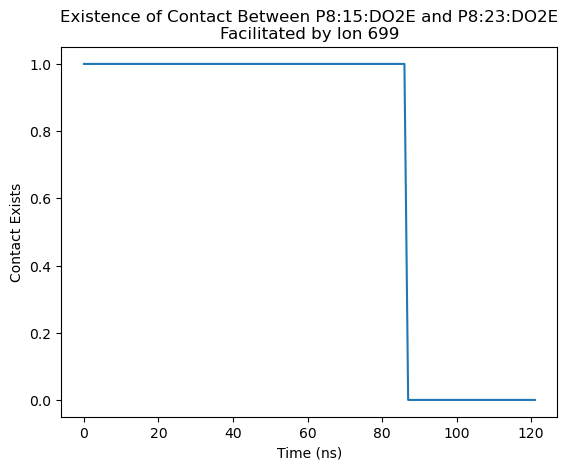

In [51]:
contact = ('699', 'P8:15:DO2E', 'P8:23:DO2E')
plt.plot(timeseries[:333:2]/1000000, interaction_states[contact])
plt.xlabel('Time (ns)')
plt.ylabel('Contact Exists')
plt.title(f'Existence of Contact Between {contact[1]} and {contact[2]}\nFacilitated by Ion {contact[0]}')

This contact disappears around time 87 ns.

All of these contacts can be plotted all at once in a heatmap as shown below.

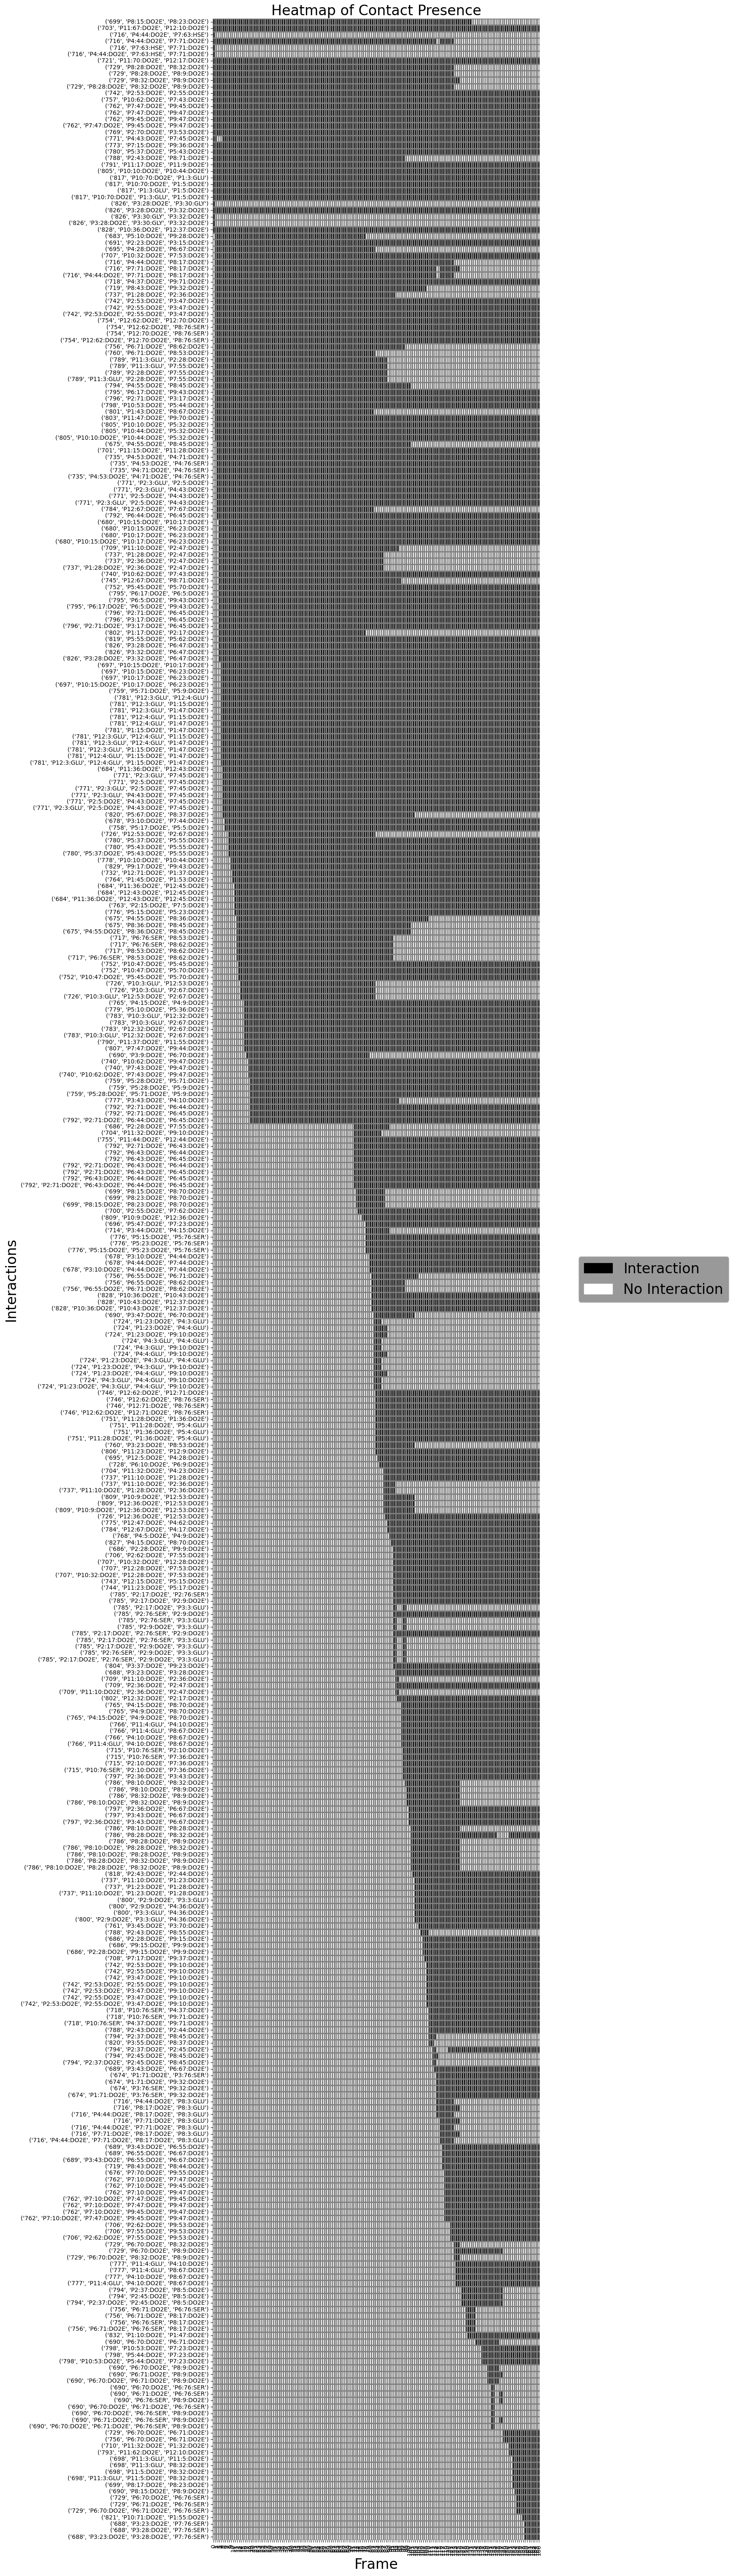

In [53]:
analyze_ion_coordination_bonds.plot_heatmap(data_dict=interaction_states,
                                            title='Heatmap of Contact Presence',
                                            time_series=None,
                                            xlabel='Frame')

## Track whether or not each contact of a specified type is present at each frame

Use track_specific_interactions_over_time to perform the analysis above for only contacts that involve all atom types specified by the function parameter atom_types.

In this case, only interactions involving 'OG312' atom types are counted.

In [61]:
specific_interaction = analyze_ion_coordination_bonds.track_specific_interactions_over_time(protein_protein_tracking=protein_track,
                                                                                            ion_surrounding_atoms_each_frame=ion_surroundings,
                                                                                            atom_types=['OG312'])

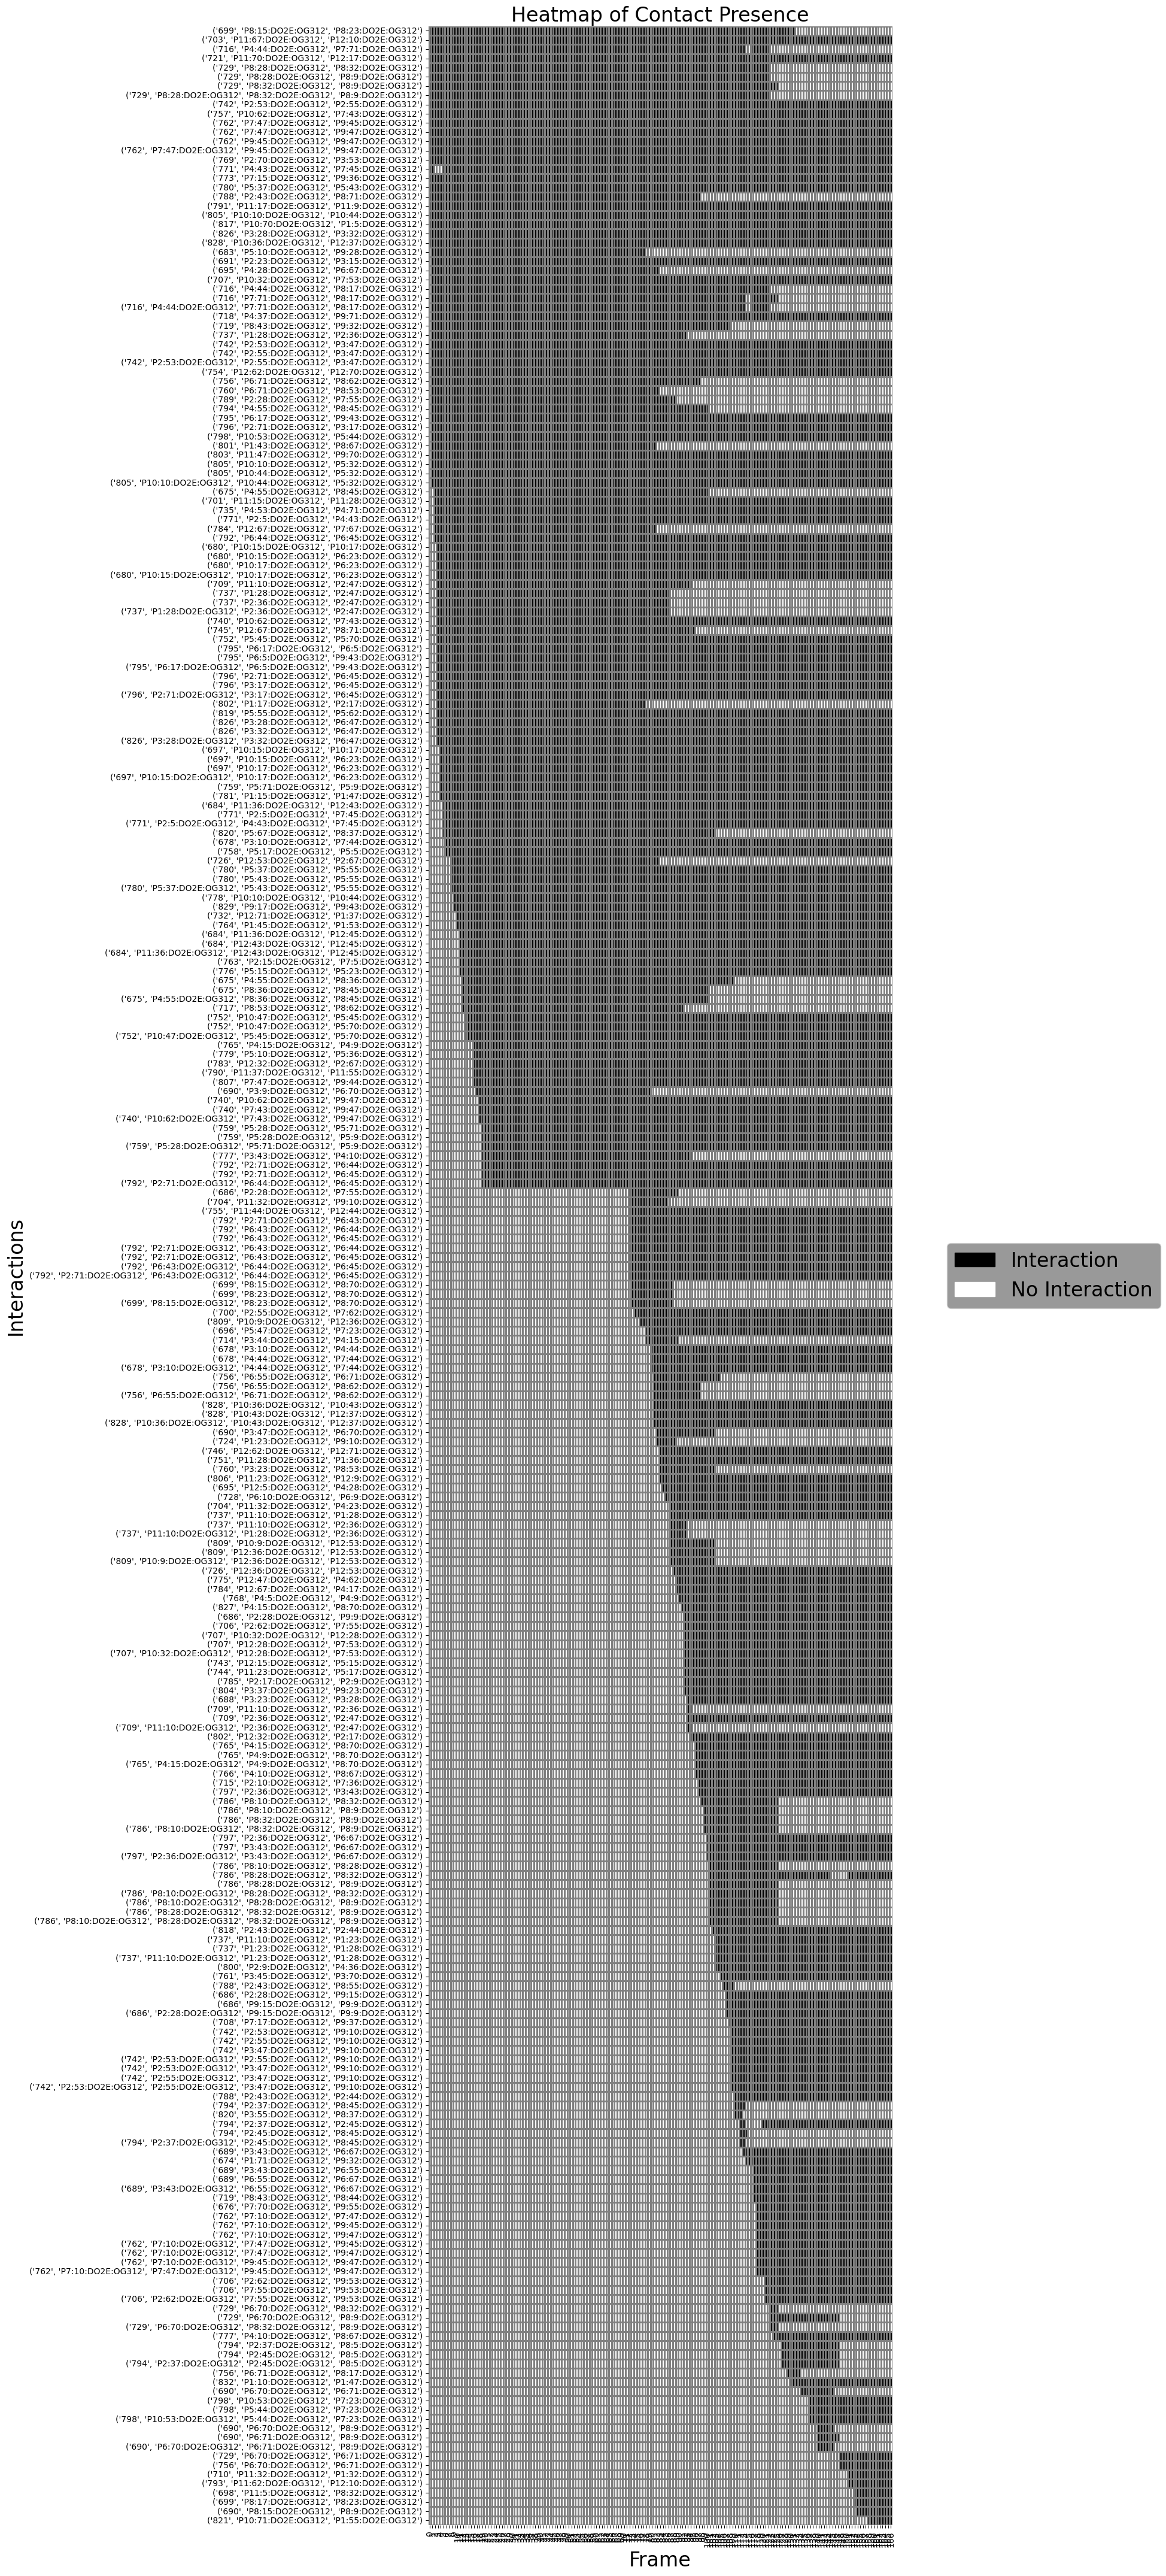

In [62]:
analyze_ion_coordination_bonds.plot_heatmap(data_dict=specific_interaction,
                                            title='Heatmap of Contact Presence',
                                            time_series=None,
                                            xlabel='Frame')

## Track existing and cumulative ruptured two-way ion-mediated protein-protein contacts through the simulation

The script below uses information from interaction states to count how many two-way ion-mediated protein-protein contacts that have formed, borken, and exist currently at each timestep throughout the simulation. Two-way means that contacts that occur between more than two residues around the same ion are excluded.

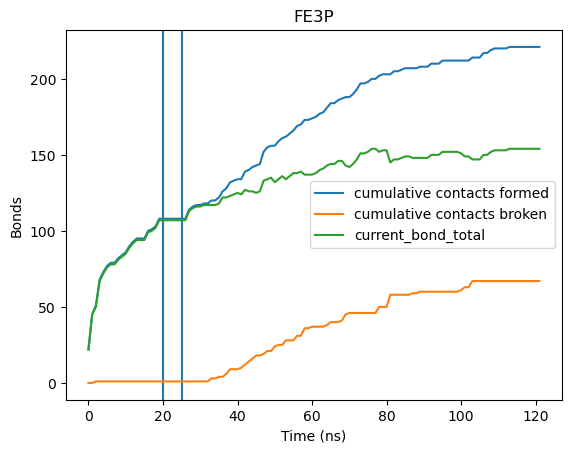

In [64]:
# Loop through the dictionary storing iron-mediated OG312-OG312 interactions.
# If the bond existed at the previous frame, but not at current frame, add 1 to bonds_broken.
# If the bond exists at the current frame, but not at the previuos frame, add 1 to bonds_formed.
time_series=timeseries[:end_idx:step]/1000000

og312_og312_bonds_formed_dict = {}
og312_og312_bonds_broken_dict = {}

sample_key = list(specific_interaction.keys())[0]
bonds_broken = np.zeros(len(specific_interaction[sample_key]))
bonds_formed = np.zeros(len(specific_interaction[sample_key]))
interaction_states = specific_interaction
for interaction in interaction_states:
    # Look for only the interactions that were collected between two divalent DOPA residues.
    if len(interaction) == 3:
            # Consider this interaction.
        for i, state in enumerate(interaction_states[interaction]):
                # If this interaction exists at the first frame, add 1 to bonds_formed[0].
            if i == 0 and state == 1:
                bonds_formed[0] += 1
                # Otherwise, check if this interaction state has changed.
            elif i != 0:
                if state - interaction_states[interaction][i-1] == 1:
                    bonds_formed[i] += 1
                elif state - interaction_states[interaction][i-1] == -1:
                    bonds_broken[i] += 1
    # Now count cumulative bonds formed and broken up to each frame.
for i in range(1, len(bonds_formed)):
    bonds_formed[i] = bonds_formed[i] + bonds_formed[i-1]
    bonds_broken[i] = bonds_broken[i] + bonds_broken[i-1]
og312_og312_bonds_formed_dict = bonds_formed
og312_og312_bonds_broken_dict = bonds_broken
fig, ax = plt.subplots()
# 20 ns is the end of the annealing at 370K.
plt.axvline(20)
# 25 ns is the start of the tensile test.
plt.axvline(25)
ax.plot(time_series[:len(bonds_formed)], bonds_formed, label='cumulative contacts formed')
ax.plot(time_series[:len(bonds_broken)], bonds_broken, label='cumulative contacts broken')
ax.plot(time_series[:len(bonds_formed)], bonds_formed - bonds_broken, label = 'current_bond_total')
ax.set_xlabel('Time (ns)')
ax.set_ylabel('Bonds')
ax.set_title(f"FE3P")
plt.legend()
plt.show()